In [ ]:
import pandas as pd

# Define column names for dataset features
columns = [
    "Elevation",
    "Aspect",
    "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am",
    "Hillshade_Noon",
    "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]

# Add one-hot encoded wilderness area columns
columns += [f"Wilderness_Area{i}" for i in range(1, 5)]

# Add one-hot encoded soil type columns
columns += [f"Soil_Type{i}" for i in range(1, 41)]

# Add target variable (forest cover type)
columns += ["Cover_Type"]

# Load dataset (original file has no header)
df = pd.read_csv("covertype/covtype.data.gz", header=None)

# Assign column names
df.columns = columns

# Print dataset shape (rows, columns)
print(df.shape)

# Print class distribution (counts per class)
print(df["Cover_Type"].value_counts().sort_index())

(581012, 55)
Cover_Type
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


In [ ]:
# Split dataset into train, validation, and test sets
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary (val + test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["Cover_Type"],  # preserve class distribution
    random_state=42
)

# Second split: temp → validation (~10%) and test (~20%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=2/3,
    stratify=temp_df["Cover_Type"],
    random_state=42
)

# Print dataset sizes
print(train_df.shape, val_df.shape, test_df.shape)


# ---- Experimental subsets (not used in final model) ----

# Smaller balanced training subset (early experiments)
# train_balanced = train_df.sample(n=28000, random_state=42).reset_index(drop=True)

# Smaller validation/test subsets for faster experimentation
# val_small = val_df.sample(n=5000, random_state=42).reset_index(drop=True)
# test_small = test_df.sample(n=5000, random_state=42).reset_index(drop=True)

# Verification checks (optional, used during debugging)
# print("Columns:", train_balanced.columns.tolist()[-5:])
# print("Balanced counts:")
# print(train_balanced["Cover_Type"].value_counts().sort_index())


# ---- Full datasets (used for final model training) ----

train_full = train_df.reset_index(drop=True)
val_full = val_df.reset_index(drop=True)
test_full = test_df.reset_index(drop=True)

# Print class distribution of training set
print("Train counts:")
print(train_full["Cover_Type"].value_counts().sort_index())

(406708, 55) (58101, 55) (116203, 55)
Train counts:
Cover_Type
1    148288
2    198310
3     25028
4      1923
5      6645
6     12157
7     14357
Name: count, dtype: int64


In [3]:
#print(df.columns.tolist())

#import torch

#counts = train_balanced["Cover_Type"].value_counts().sort_index()
#total = counts.sum()

#weights = total / (len(counts) * counts)
#weights = torch.tensor(weights.values, dtype=torch.float)

#print("Class weights:", weights)

In [ ]:
# Check class distribution (proportions) across splits

print("Original:")
print(df["Cover_Type"].value_counts(normalize=True).sort_index())

print("\nTrain:")
print(train_df["Cover_Type"].value_counts(normalize=True).sort_index())

print("\nValidation:")
print(val_df["Cover_Type"].value_counts(normalize=True).sort_index())

print("\nTest:")
print(test_df["Cover_Type"].value_counts(normalize=True).sort_index())

Original:
Cover_Type
1    0.364605
2    0.487599
3    0.061537
4    0.004728
5    0.016339
6    0.029891
7    0.035300
Name: proportion, dtype: float64

Train:
Cover_Type
1    0.364606
2    0.487598
3    0.061538
4    0.004728
5    0.016339
6    0.029891
7    0.035301
Name: proportion, dtype: float64

Validation:
Cover_Type
1    0.364606
2    0.487599
3    0.061531
4    0.004733
5    0.016334
6    0.029896
7    0.035301
Name: proportion, dtype: float64

Test:
Cover_Type
1    0.364603
2    0.487604
3    0.061539
4    0.004724
5    0.016342
6    0.029887
7    0.035300
Name: proportion, dtype: float64


In [ ]:
# Define column groups for one-hot encoded features
wilderness_cols = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_cols = [f"Soil_Type{i}" for i in range(1, 41)]

# Convert one-hot encoded columns into a single index value
def get_active_index(row, cols):
    for i, col in enumerate(cols, start=1):
        if row[col] == 1:
            return i
    return 0  # fallback (should not normally happen)

# Convert a dataset row into a structured text prompt for the LLM
def row_to_prompt(row):
    wilderness = get_active_index(row, wilderness_cols)
    soil = get_active_index(row, soil_cols)

    return f"""Task: Predict the forest cover type.

Valid labels:
<C1>, <C2>, <C3>, <C4>, <C5>, <C6>, <C7>

Now classify this:

Features:
Elevation={row['Elevation']}
Aspect={row['Aspect']}
Slope={row['Slope']}
Horizontal_Distance_To_Hydrology={row['Horizontal_Distance_To_Hydrology']}
Vertical_Distance_To_Hydrology={row['Vertical_Distance_To_Hydrology']}
Horizontal_Distance_To_Roadways={row['Horizontal_Distance_To_Roadways']}
Hillshade_9am={row['Hillshade_9am']}
Hillshade_Noon={row['Hillshade_Noon']}
Hillshade_3pm={row['Hillshade_3pm']}
Horizontal_Distance_To_Fire_Points={row['Horizontal_Distance_To_Fire_Points']}
Wilderness_Area={wilderness}
Soil_Type={soil}

Rules:
- Output exactly one label
- Do not explain

Answer:"""

# Convert numeric class label into token format (<C1>–<C7>)
def label_to_token(label):
    return f"<C{int(label)}>"

In [ ]:
# Build custom dataset for LLM training
import torch
from torch.utils.data import Dataset

class CovertypeLLMDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=224):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Convert row to prompt + label token
        prompt = row_to_prompt(row)
        label_text = " " + label_to_token(row["Cover_Type"])
        full_text = prompt + label_text

        # Tokenize full input (prompt + label)
        full_enc = self.tokenizer(
            full_text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        # Tokenize prompt separately to find where label starts
        prompt_enc = self.tokenizer(
            prompt,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        input_ids = full_enc["input_ids"].squeeze(0)
        attention_mask = full_enc["attention_mask"].squeeze(0)

        # Copy input_ids as labels and mask prompt tokens
        labels = input_ids.clone()
        prompt_len = int(prompt_enc["attention_mask"].sum().item())

        # Ignore prompt + padding tokens during loss
        labels[:prompt_len] = -100
        labels[attention_mask == 0] = -100

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

In [ ]:
# Load tokenizer and model (decoder-only LLM)
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "distilgpt2"

# Load pretrained tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Set padding token (GPT models do not have one by default)
tokenizer.pad_token = tokenizer.eos_token

# Add special tokens for class labels (<C1>–<C7>)
special_tokens = {
    "additional_special_tokens": [f"<C{i}>" for i in range(1, 8)]
}
tokenizer.add_special_tokens(special_tokens)

# Load pretrained model
model = AutoModelForCausalLM.from_pretrained(model_name)

# Resize embedding layer to include new tokens
model.resize_token_embeddings(len(tokenizer))

# Set padding token ID in model configuration
model.config.pad_token_id = tokenizer.pad_token_id

# Disable caching during training (required for Trainer compatibility)
model.config.use_cache = False

c:\Users\tragh\Documents\ML_Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 76/76 [00:00<00:00, 15200.38it/s]
[transformers] The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


In [ ]:
# train/val/test 

train_dataset = CovertypeLLMDataset(train_full, tokenizer, max_length=224)
val_dataset = CovertypeLLMDataset(val_full, tokenizer, max_length=224)
test_dataset = CovertypeLLMDataset(test_full, tokenizer, max_length=224)

print("train size:", len(train_dataset))
print("val size:", len(val_dataset))

sample = train_dataset[0]
print("Labels not masked:", (sample["labels"] != -100).sum().item())

train size: 406708
val size: 58101
Labels not masked: 2


In [ ]:
# check prompt length
row = train_full.iloc[0]
prompt = row_to_prompt(row)

print(prompt)
print("Token length:", len(tokenizer(prompt)["input_ids"]))

Task: Predict the forest cover type.

Valid labels:
<C1>, <C2>, <C3>, <C4>, <C5>, <C6>, <C7>

Now classify this:

Features:
Elevation=2823
Aspect=30
Slope=29
Horizontal_Distance_To_Hydrology=162
Vertical_Distance_To_Hydrology=46
Horizontal_Distance_To_Roadways=1150
Hillshade_9am=198
Hillshade_Noon=165
Hillshade_3pm=87
Horizontal_Distance_To_Fire_Points=1746
Wilderness_Area=3
Soil_Type=24

Rules:
- Output exactly one label
- Do not explain

Answer:
Token length: 171


In [10]:
print("df:", "Cover_Type" in df.columns)
print("train_df:", "Cover_Type" in train_df.columns)
print(train_df.columns.tolist()[-5:])

df: True
train_df: True
['Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Cover_Type']


In [11]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_arch_list())

2.11.0+cu128
12.8
True
NVIDIA GeForce RTX 5060 Ti
['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [ ]:
import torch.nn as nn
from transformers import Trainer

# Custom Trainer to apply class weighting at the token level
class WeightedTrainer(Trainer):
    def __init__(self, vocab_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.vocab_weights = vocab_weights  # weights for each token in vocab

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]

        # Forward pass
        outputs = model(**inputs)
        logits = outputs.logits

        # Cross-entropy loss with class/token weights
        loss_fct = nn.CrossEntropyLoss(
            weight=self.vocab_weights.to(logits.device),
            ignore_index=-100  # ignore prompt + padding tokens
        )

        # Shift for causal language modeling (next-token prediction)
        shift_logits = logits[..., :-1, :].contiguous()
        shift_labels = labels[..., 1:].contiguous()

        # Compute loss only on valid (unmasked) tokens
        loss = loss_fct(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1)
        )

        return (loss, outputs) if return_outputs else loss

In [ ]:
# Training on FULL dataset (no class weighting)
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score
import numpy as np
import torch

# Compute accuracy (ignores masked tokens)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    # Only evaluate on label tokens (ignore prompt + padding)
    mask = labels != -100
    labels = labels[mask]
    predictions = predictions[mask]

    return {
        "accuracy": accuracy_score(labels, predictions)
    }

# Training configuration
training_args = TrainingArguments(
    output_dir="./llm_covertype_full",

    # No evaluation during training (due to memory constraints)
    eval_strategy="no",

    # Save checkpoints periodically
    save_strategy="steps",
    save_steps=5000,
    save_total_limit=2,

    # Logging setup
    logging_strategy="steps",
    logging_steps=100,

    # Small batch size due to GPU memory limits
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,  # simulate larger batch size
    per_device_eval_batch_size=2,

    # Training parameters
    num_train_epochs=7,
    learning_rate=1e-4,
    weight_decay=0.01,

    # Use mixed precision if GPU supports it
    fp16=torch.cuda.is_available(),

    # Required for custom dataset format
    remove_unused_columns=False,

    # Disable external logging
    report_to="none"
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,  # used for manual evaluation later
    compute_metrics=compute_metrics
)

print(type(trainer))

# Resume training from checkpoint (if one exists)
trainer.train(resume_from_checkpoint=True)

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


<class 'transformers.trainer.Trainer'>


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
600100,0.142122
600200,0.233682
600300,0.194104
600400,0.172177
600500,0.142859
600600,0.166289
600700,0.144793
600800,0.129930
600900,0.155928
601000,0.137055


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.10it/s]


TrainOutput(global_step=711739, training_loss=0.022511589334667167, metrics={'train_runtime': 6465.2708, 'train_samples_per_second': 440.346, 'train_steps_per_second': 110.086, 'total_flos': 1.6272820197339955e+17, 'train_loss': 0.022511589334667167, 'epoch': 7.0})

In [ ]:
# Generate prediction for a single row using the trained LLM
def predict_label(row, model, tokenizer, max_new_tokens=5, device="cpu"):
    # Convert row into prompt format
    prompt = row_to_prompt(row)

    # Tokenize prompt
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=224
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Store length of input to separate generated output later
    input_len = inputs["input_ids"].shape[1]

    # Generate output tokens (model predicts next tokens)
    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,  # deterministic (greedy decoding)
            pad_token_id=tokenizer.pad_token_id
        )

    # Extract only newly generated tokens (exclude prompt)
    generated_ids = output_ids[0][input_len:]

    # Decode tokens into text
    decoded = tokenizer.decode(generated_ids, skip_special_tokens=False)

    # Find which class token was generated
    for i in range(1, 8):
        if f"<C{i}>" in decoded:
            return i

    return None  # fallback if no class token is found

In [15]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50264, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-5): 6 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50264, bias=False)
)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import torch

# Set device (GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()  # set model to evaluation mode

# Valid class labels
valid_labels = [1, 2, 3, 4, 5, 6, 7]

# Store true and predicted labels
y_true = []
y_pred = []

# Use full validation dataset
sample_val_df = val_full

# Generate predictions row by row
for _, row in sample_val_df.iterrows():
    pred = predict_label(row, model, tokenizer, device=device)

    # Skip invalid outputs (if model doesn't return a valid class)
    if pred not in valid_labels:
        continue

    y_true.append(int(row["Cover_Type"]))
    y_pred.append(int(pred))

# Print number of valid predictions
print("Validation valid predictions:", len(y_pred))

# Evaluate performance
if len(y_pred) > 0:
    print("Validation Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, labels=valid_labels, digits=4))
else:
    print("No valid validation predictions were generated.")

Validation valid predictions: 58101
Validation Accuracy: 0.8419132200822705
              precision    recall  f1-score   support

           1     0.7787    0.9418    0.8525     21184
           2     0.9038    0.8206    0.8602     28330
           3     0.7846    0.8459    0.8141      3575
           4     0.8496    0.6982    0.7665       275
           5     0.8817    0.3298    0.4801       949
           6     0.8978    0.4145    0.5672      1737
           7     0.9652    0.7157    0.8219      2051

    accuracy                         0.8419     58101
   macro avg     0.8659    0.6809    0.7375     58101
weighted avg     0.8522    0.8419    0.8378     58101



In [ ]:
# Evaluate model on test set
from sklearn.metrics import classification_report, accuracy_score
import torch

# Set device (use GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()  # set model to evaluation mode

# Store true and predicted labels
y_true = []
y_pred = []

# Valid class labels
valid_labels = [1, 2, 3, 4, 5, 6, 7]

# Use full test dataset
sample_test_df = test_full

# Generate predictions for each sample
for _, row in sample_test_df.iterrows():
    pred = predict_label(row, model, tokenizer, device=device)

    # Skip invalid outputs (if model doesn't return a valid class)
    if pred not in valid_labels:
        continue

    y_true.append(int(row["Cover_Type"]))
    y_pred.append(int(pred))

# Print number of valid predictions
print("Number of valid predictions:", len(y_pred))

# Compute evaluation metrics
if len(y_pred) > 0:
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print(classification_report(y_true, y_pred, labels=valid_labels, digits=4))
else:
    print("No valid predictions were generated.")

Number of valid predictions: 116203
Accuracy: 0.8416822285138937
              precision    recall  f1-score   support

           1     0.7799    0.9421    0.8533     42368
           2     0.9018    0.8219    0.8600     56661
           3     0.7885    0.8430    0.8148      7151
           4     0.8618    0.7268    0.7885       549
           5     0.8669    0.3086    0.4551      1899
           6     0.8850    0.3965    0.5476      3473
           7     0.9632    0.7153    0.8209      4102

    accuracy                         0.8417    116203
   macro avg     0.8639    0.6791    0.7343    116203
weighted avg     0.8513    0.8417    0.8371    116203



In [18]:
import sys
print(sys.executable)

import transformers
print(transformers.__version__)

c:\Users\tragh\Documents\ML_Project\venv\Scripts\python.exe
5.6.2


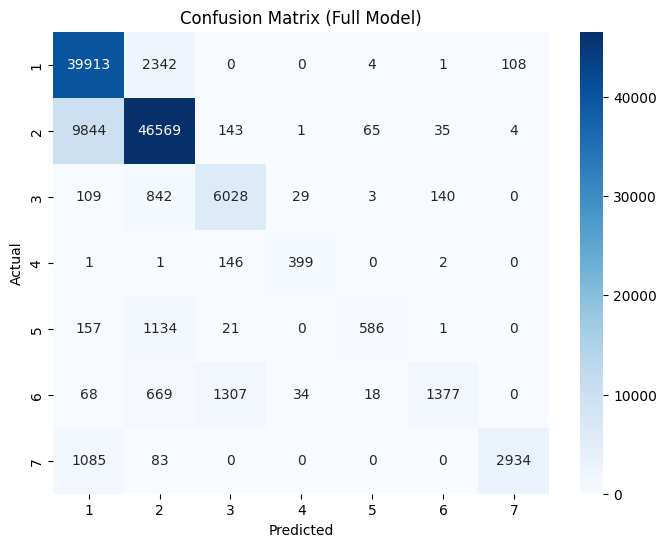

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred, labels=[1,2,3,4,5,6,7])

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=[1,2,3,4,5,6,7],
            yticklabels=[1,2,3,4,5,6,7])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Full Model)")
plt.show()

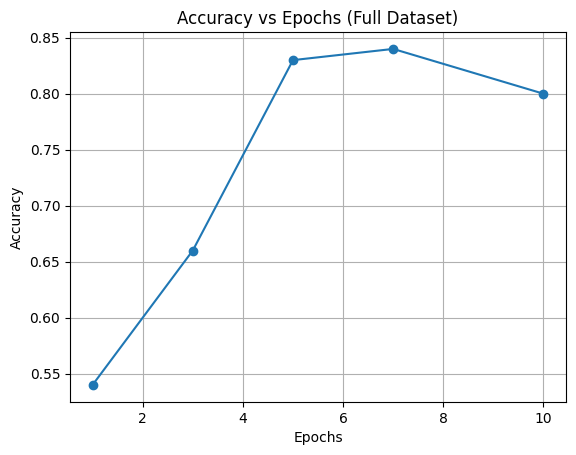

In [23]:
epochs = [1, 3, 5, 7, 10]
accuracy = [0.54, 0.66, 0.83, 0.84, 0.80]

plt.plot(epochs, accuracy, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs (Full Dataset)")
plt.grid()
plt.show()

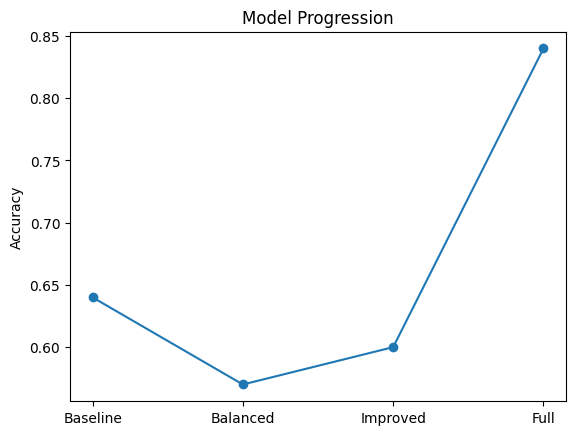

In [24]:
models = ["Baseline", "Balanced", "Improved", "Full"]
accuracy = [0.64, 0.57, 0.60, 0.84]

plt.plot(models, accuracy, marker='o')
plt.title("Model Progression")
plt.ylabel("Accuracy")
plt.show()

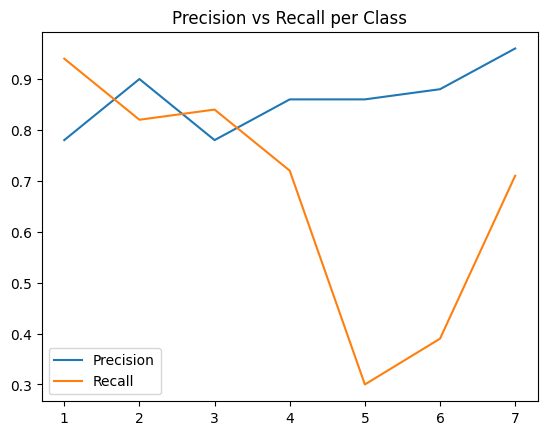

In [26]:
precision = [0.78, 0.90, 0.78, 0.86, 0.86, 0.88, 0.96]
recall    = [0.94, 0.82, 0.84, 0.72, 0.30, 0.39, 0.71]
classes = [1, 2, 3, 4, 5, 6, 7]

plt.plot(classes, precision, label="Precision")
plt.plot(classes, recall, label="Recall")

plt.legend()
plt.title("Precision vs Recall per Class")
plt.show()